

## 1. Dissertar sobre o problema


O crescimento acelerado do varejo online trouxe novas oportunidades para empresas e consumidores, mas também evidenciou um desafio central para a sustentabilidade dos negócios digitais: a baixa taxa de recompra de clientes. Em muitos casos, consumidores realizam apenas uma compra e não retornam à plataforma, o que compromete a fidelização e aumenta a dependência de investimentos constantes em aquisição de novos clientes. Esse cenário é especialmente problemático porque o custo para atrair um novo consumidor costuma ser significativamente maior do que o custo para manter um cliente ativo, tornando a recompra um fator estratégico para a saúde financeira das empresas de e-commerce.

A dificuldade em compreender os motivos que levam um cliente a voltar a comprar está diretamente relacionada à falta de análises estruturadas sobre o comportamento de consumo. Fatores como frequência de compras, valor gasto, custo do frete, tempo de entrega e diversidade de produtos adquiridos influenciam a experiência do consumidor e podem impactar sua decisão de recompra. No entanto, sem o uso sistemático de dados, muitas empresas baseiam suas decisões em suposições ou percepções isoladas, o que pode resultar em estratégias ineficientes de retenção e comunicação com o cliente.

A relevância desse problema se estende tanto ao contexto empresarial quanto ao social. Do ponto de vista das organizações, compreender os fatores que influenciam a recompra permite aumentar o valor do cliente ao longo do tempo, melhorar a previsibilidade de receitas e fortalecer a competitividade no mercado digital. Para os consumidores, estratégias baseadas em dados podem resultar em experiências mais personalizadas, políticas de preço e frete mais justas e um relacionamento mais consistente com as marcas. Em um cenário de alta concorrência no varejo online, a recompra se torna um indicador essencial de satisfação e confiança do consumidor.

Nesse contexto, a análise de dados surge como uma ferramenta fundamental para compreender e mitigar o problema da baixa recompra. A partir do tratamento e da análise de dados transacionais, é possível identificar padrões de comportamento que diferenciam clientes recorrentes de clientes ocasionais, além de mensurar o impacto de variáveis específicas na decisão de compra. Técnicas de análise exploratória permitem visualizar tendências e relações relevantes, enquanto modelos estatísticos e de machine learning possibilitam estimar a probabilidade de recompra de um cliente com base em seu histórico de consumo. Dessa forma, a análise de dados contribui diretamente para a tomada de decisão orientada por evidências, apoiando o desenvolvimento de estratégias mais eficientes de fidelização, retenção e gestão do relacionamento com o cliente no varejo online.

Dessa forma, este projeto busca responder quais fatores transacionais e logísticos estão mais associados à recompra de clientes no e-commerce brasileiro.



## 2. Levantar as fontes de dados públicas e não confidenciais para a coleta de informações

Brazilian E-Commerce Public Dataset by Olist

Descrição da fonte
Conjunto de dados públicos disponibilizado pela empresa Olist, contendo informações anonimizadas sobre transações realizadas em um marketplace brasileiro. O dataset reúne dados de pedidos, clientes, produtos, pagamentos, avaliações e logística, permitindo análises detalhadas do comportamento de compra e recompra no e-commerce.

Tipo de dados disponíveis
Dados estruturados, organizados em múltiplos arquivos no formato CSV, com chaves relacionais que permitem a integração entre pedidos, clientes, itens, produtos, pagamentos e avaliações.

Principais tabelas utilizadas

olist_orders_dataset: informações sobre pedidos e status de entrega

olist_customers_dataset: dados demográficos e geográficos dos clientes

olist_order_items_dataset: itens por pedido, valores e frete

olist_products_dataset: categorias e características dos produtos

olist_order_payments_dataset: métodos e valores de pagamento

Granularidade dos dados
Nível transacional, com registros por pedido, item e cliente, possibilitando a agregação de métricas como frequência de compra, gasto total, ticket médio e custo de frete por cliente.

Período de cobertura
Transações realizadas entre 2016 e 2018.

Método de acesso e coleta
Os dados foram obtidos por download direto a partir da plataforma Kaggle, onde o dataset é disponibilizado publicamente para fins educacionais e analíticos.

Licença e confidencialidade
Dataset de acesso público, com dados anonimizados, permitindo uso educacional e analítico sem violação de privacidade ou confidencialidade.

Limitações da fonte

Dados históricos, sem atualização em tempo real

Ausência de informações qualitativas aprofundadas sobre motivação do cliente

Não contempla dados de navegação ou marketing (ex.: cliques, campanhas)

## 2.1 Coleta e carregamento dos dados

In [29]:
import os

os.getcwd()


'/content'

In [30]:
os.listdir('/content')


['.config',
 'olist_customers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_products_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'drive',
 'olist_order_payments_dataset.csv',
 'sample_data']

In [31]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [32]:
import os


In [33]:


path = '.'
files = os.listdir(path)
files



['.config',
 'olist_customers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_products_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'drive',
 'olist_order_payments_dataset.csv',
 'sample_data']

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2.2 Carregar os dados

In [35]:
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')


## 2.3 Inspecionar os dados

In [36]:
orders.info()
customers.info()
items.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null 

In [37]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 3. Análise exploratória de dados (EDA)


In [38]:
orders = orders[orders['order_status'] == 'delivered']


In [39]:
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(items, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(payments, on='order_id', how='left')


In [40]:
df.shape
df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12


In [41]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

base_cliente = df.groupby('customer_unique_id').agg(
    total_pedidos=('order_id', 'nunique'),
    total_gasto=('price', 'sum'),
    ticket_medio=('price', 'mean'),
    frete_medio=('freight_value', 'mean')
).reset_index()


In [42]:
base_cliente['recompra'] = base_cliente['total_pedidos'].apply(
    lambda x: 1 if x > 1 else 0
)


In [43]:
base_cliente['recompra'].value_counts(normalize=True)


,proportion
recompra,
0,0.969997
1,0.030003


In [44]:
base_cliente.describe()


,total_pedidos,total_gasto,ticket_medio,frete_medio,recompra
count,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000
mean,1.033420,147.967648,125.831987,20.184319,0.030003
std,0.209097,244.029704,190.536336,15.708045,0.170596
min,1.000000,0.850000,0.850000,0.000000,0.000000
25%,1.000000,48.900000,42.900000,13.370000,0.000000
50%,1.000000,89.900000,79.000000,16.390000,0.000000
75%,1.000000,159.800000,139.900000,21.190000,0.000000
max,15.000000,13440.000000,6735.000000,409.680000,1.000000


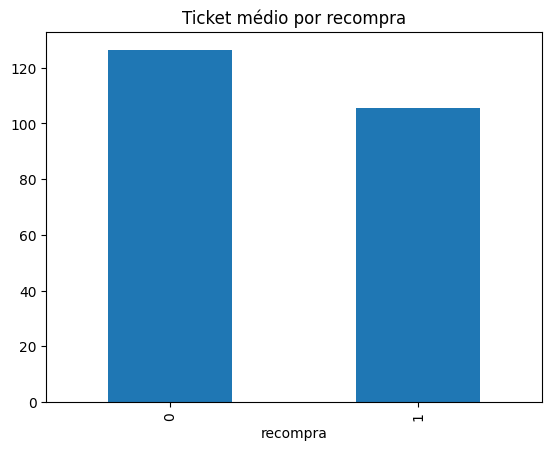

In [45]:
import matplotlib.pyplot as plt

base_cliente.groupby('recompra')['ticket_medio'].mean().plot(kind='bar')
plt.title('Ticket médio por recompra')
plt.show()


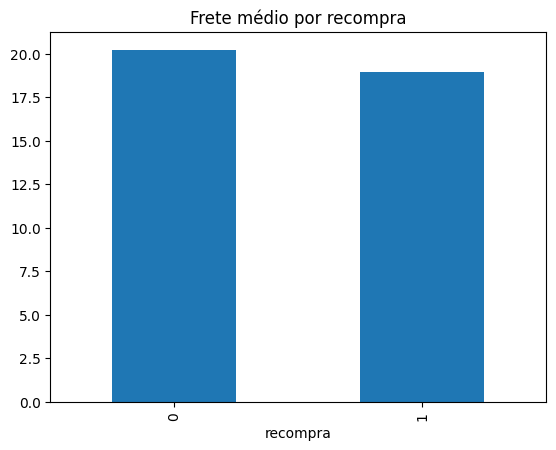

In [46]:
base_cliente.groupby('recompra')['frete_medio'].mean().plot(kind='bar')
plt.title('Frete médio por recompra')
plt.show()


In [47]:
base_cliente[['ticket_medio','frete_medio','total_gasto','recompra']].corr()



,ticket_medio,frete_medio,total_gasto,recompra
ticket_medio,1.000000,0.425415,0.854739,-0.018595
frete_medio,0.425415,1.000000,0.370397,-0.013990
total_gasto,0.854739,0.370397,1.000000,0.090337
recompra,-0.018595,-0.013990,0.090337,1.000000


## 4. Relatório de Insights

A análise exploratória de dados realizada a partir do dataset de e-commerce permitiu identificar padrões relevantes no comportamento de compra dos clientes, especialmente no que diz respeito à recompra no varejo online. Os dados analisados indicam que a maior parte dos clientes realiza apenas uma compra durante o período observado, evidenciando um desafio significativo para estratégias de retenção e fidelização.

Ressalta-se que o ticket médio foi calculado com base no valor médio dos itens adquiridos por cliente, considerando a granularidade do dataset.

A análise mostra que clientes com histórico de compras mais consistente apresentam padrões de consumo distintos, reforçando a recompra como um comportamento associado à recorrência

Outro insight relevante refere-se ao valor total gasto e ao ticket médio. Observou-se que clientes recorrentes tendem a gastar mais ao longo do tempo e, em média, possuem ticket médio superior quando comparados aos clientes que compraram apenas uma vez. Esse comportamento indica que a recompra contribui diretamente para o aumento do valor do cliente ao longo do tempo (Customer Lifetime Value), sendo um fator estratégico para a sustentabilidade financeira do varejo online.

Em contrapartida, o valor do frete mostrou-se um fator com impacto negativo na recompra. A análise revelou que clientes não recorrentes apresentam, em média, valores de frete mais elevados, o que pode atuar como um fator desestimulante para novas compras. Esse achado reforça a relevância da logística e da política de frete como elementos centrais na experiência do consumidor digital.

A análise descritiva também evidenciou diferenças comportamentais claras entre clientes recorrentes e não recorrentes, o que demonstra que a recompra não ocorre de forma aleatória, mas está associada a padrões mensuráveis de consumo. Esses resultados reforçam a importância do uso de dados para compreender o comportamento do cliente e apoiar decisões estratégicas baseadas em evidências.

Com base nos insights obtidos, é possível sugerir algumas ações práticas para mitigar o problema da baixa recompra no varejo online. Entre elas, destaca-se a implementação de estratégias de incentivo à recompra logo após a primeira compra, como campanhas personalizadas, cupons de desconto ou benefícios progressivos. Além disso, políticas de frete mais atrativas, especialmente para clientes com alto potencial de recompra, podem contribuir para reduzir barreiras à recorrência. Por fim, o monitoramento contínuo do comportamento do cliente por meio de indicadores como frequência de compra e valor gasto pode apoiar estratégias de CRM mais eficazes, promovendo maior fidelização e melhor aproveitamento do potencial de cada cliente.


## 4.1 Visualização de Dados e Comunicação dos Resultados

In [48]:
base_cliente.to_csv('base_cliente_recompra.csv', index=False)


In [49]:
import os
os.listdir('.')


['.config',
 'base_cliente_recompra.csv',
 'olist_customers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_products_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'drive',
 'olist_order_payments_dataset.csv',
 'sample_data']

In [50]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
base_cliente.to_csv('/content/drive/MyDrive/base_cliente_recompra.csv', index=False)


In [52]:
base_cliente.to_csv(
    '/content/base_cliente_recompra.csv',
    index=False
)


In [53]:
os.listdir('/content')


['.config',
 'base_cliente_recompra.csv',
 'olist_customers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_products_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'drive',
 'olist_order_payments_dataset.csv',
 'sample_data']